In [1]:
%load_ext autoreload
%autoreload 2

Currently using IceCubeDataset since it is compatible with my data

In [8]:
from polarbert.icecube_dataset import IceCubeDataset, train_validation_loaders

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import torch

In [29]:
def default_transform(x, l):
    # Ensure a writable copy is returned
    return x.astype(np.float32).copy(), l.astype(np.int32).copy()

def default_target_transform(y, c):
    return y, c.astype(np.float32)

In [30]:
dataset = IceCubeDataset(
        '/groups/pheno/inar/prometheus_data/memmaped_pulses', 
        batch_size=32,
        transform=default_transform, 
        target_transform=default_target_transform
    )

In [31]:
from torch.utils.data import DataLoader
dataloader = DataLoader(
        dataset, batch_size=None, num_workers=1,
        pin_memory=False, persistent_workers=True)

In [32]:
for batch in dataloader:
    break

/lustre/hpc/pheno/inar/mambaforge/envs/polarbert/lib/python3.11/site-packages/torch/utils/data/_utils/collate.py:70: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1728945388353/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  return torch.as_tensor(data)


In [33]:
(x, l), (y, c) = batch

batch_size, max_seq_len, _ = x.shape
padding_mask = torch.arange(max_seq_len, device=x.device)[None, :] >= l[:, None]

# Get charge values (feature index 1)
charges = x[:, :, 1]

Total non-masked charges collected: 195653


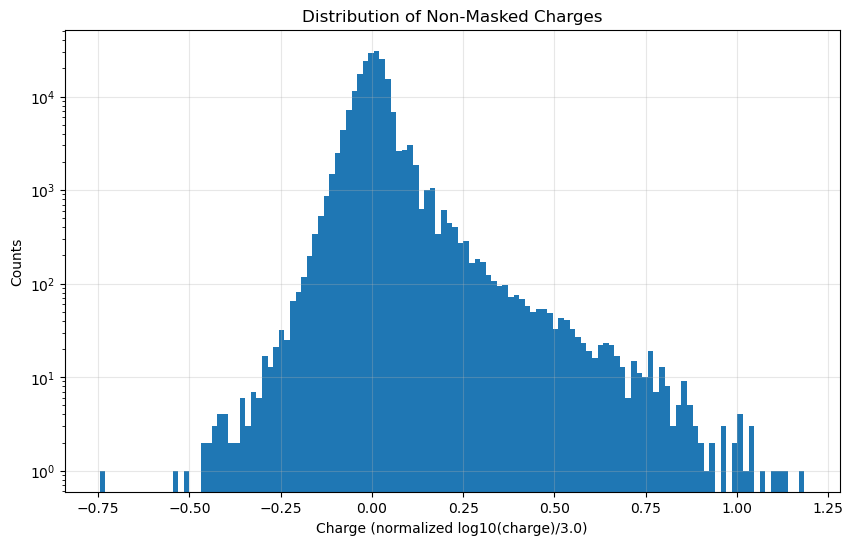

In [34]:
charges_non_masked = []

for i, batch in enumerate(dataloader):
    (x, l), (y, c) = batch
    
    # Create padding mask (same as in embedding.py)
    batch_size, max_seq_len, _ = x.shape
    padding_mask = torch.arange(max_seq_len, device=x.device)[None, :] >= l[:, None]
    
    # Get charge values (feature index 1)
    charges = x[:, :, 1]
    
    # Create mask for non-padded positions
    non_pad_mask = ~padding_mask

    auxiliary_mask = x[:, :, 2] == -0.5  # Non-auxiliary pulses
    combined_mask = non_pad_mask & auxiliary_mask
    
    # Extract only non-padded charges
    valid_charges = charges[combined_mask]
    
    # Append to our collection
    charges_non_masked.append(valid_charges)
    
    if i > 200:
        break

# Concatenate all charges into a single tensor
charges_non_masked = torch.cat(charges_non_masked)
print(f"Total non-masked charges collected: {len(charges_non_masked)}")

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(charges_non_masked.cpu().numpy(), bins=126)
plt.xlabel("Charge (normalized log10(charge)/3.0)")
plt.ylabel("Counts")
plt.yscale("log")
plt.title("Distribution of Non-Masked Charges")
plt.grid(alpha=0.3)

**We see that the charge distribution is wider than the one in the Kaggle dataset**

In [36]:
from polarbert.time_embedding import IceCubeTimeEmbedding
from polarbert.config import PolarBertConfig

In [37]:
config_file = "/groups/pheno/inar/PolarBERT/configs/polarbert_new.yaml"
config = PolarBertConfig.from_yaml(config_file)
embedding = IceCubeTimeEmbedding(config, masking=True)

Loading configuration from: /groups/pheno/inar/PolarBERT/configs/polarbert_new.yaml
Validating configuration...
Configuration validation passed (with potential warnings).
INFO: Concatenated embeddings directly match model embedding dim. No projection layer used.


/lustre/hpc/pheno/inar/PolarBERT/src/polarbert/config.py:327: UserWarning: training.final_div_factor (0.133333) is less than 1.0. For OneCycleLR, this usually leads to a high final LR. Expected >= 1.0 (e.g., 1e4).
  warnings.warn(f"training.final_div_factor ({train_cfg.final_div_factor}) is less than 1.0. "


In [38]:
for batch in dataloader:
    break
(x, l), (y, c) = batch

full_embedding, padding_mask, mask = embedding.forward((x,l))

# Evaluation

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import os
from tqdm.notebook import tqdm # Use notebook tqdm for progress
import math

# --- Assume these are imported or defined ---
try:
    from polarbert.config import PolarBertConfig
    from polarbert.time_embed_polarbert import PolarBertModel # Your new model class
    # Need the appropriate IceCubeDataset class for Prometheus data
    from polarbert.icecube_dataset import IceCubeDataset as PrometheusIceCubeDataset
    # Define default transforms if needed by the dataset class
    def default_transform(x, l): return x.astype(np.float32).copy(), l.astype(np.int32).copy()
    def default_target_transform(y, c): return y, c.astype(np.float32)
except ImportError as e:
    print(f"Error importing project modules: {e}")
    print("Please ensure classes are defined and accessible.")
    raise e

# --- Configuration ---
print("--- Evaluation Setup ---")
PROMETHEUS_DATA_DIR = '/groups/pheno/inar/prometheus_data/memmaped_pulses'
CHECKPOINT_DIR = '/groups/pheno/inar/PolarBERT/checkpoints/te_polarbert_100M_2ep_250414-011046'
# Choose specific checkpoint file (e.g., last or a specific epoch)
CHECKPOINT_FILE = os.path.join(CHECKPOINT_DIR, 'last.ckpt')
CONFIG_FILE = os.path.join(CHECKPOINT_DIR, 'config.yaml') # Config saved by callback

EVAL_BATCH_SIZE = 32 # Small batch size for CPU
NUM_EVAL_BATCHES = 1000 # Number of batches to evaluate from Prometheus
DEVICE = torch.device('cpu') # Explicitly use CPU
print(f"Using device: {DEVICE}")
print(f"Evaluating checkpoint: {CHECKPOINT_FILE}")
print(f"Using Prometheus data from: {PROMETHEUS_DATA_DIR}")


--- Evaluation Setup ---
Using device: cpu
Evaluating checkpoint: /groups/pheno/inar/PolarBERT/checkpoints/te_polarbert_100M_2ep_250414-011046/last.ckpt
Using Prometheus data from: /groups/pheno/inar/prometheus_data/memmaped_pulses


In [54]:

# --- 1. Load Config from Checkpoint Directory ---
if not os.path.exists(CONFIG_FILE):
    print(f"ERROR: Config file not found at {CONFIG_FILE}. Cannot proceed.")
    # Or try loading from ExperimentConfig.from_checkpoint if that handles finding config.yaml
    # config = PolarBertConfig.from_checkpoint(CHECKPOINT_FILE)
    raise FileNotFoundError(f"Config file not found: {CONFIG_FILE}")
else:
    config = PolarBertConfig.from_yaml(CONFIG_FILE)
    print("Loaded configuration associated with checkpoint.")
    # Override masking prob based on how you want to eval (usually False during eval)
    # config.model.embedding.masking_prob = 0.0 # Disable stochastic masking if model uses it


Loading configuration from: /groups/pheno/inar/PolarBERT/checkpoints/te_polarbert_100M_2ep_250414-011046/config.yaml
Validating configuration...
Configuration validation passed (with potential warnings).
Loaded configuration associated with checkpoint.


In [55]:

# --- 2. Instantiate Model ---
print("Instantiating model...")
# Pass masking=False if you want deterministic eval without mask replacement
# If your loss calc relies on the mask output, pass masking=True
model = PolarBertModel(config) # masking=True needed if loss uses output_mask



Instantiating model...
INFO: Concatenated embeddings directly match model embedding dim. No projection layer used.


In [56]:

# --- 3. Load Checkpoint Weights ---
print("Loading model weights...")
try:
    checkpoint = torch.load(CHECKPOINT_FILE, map_location=DEVICE)
    # Check if state_dict key exists (standard PL checkpoint)
    if 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        # Assume the loaded object *is* the state_dict (less common for PL)
        state_dict = checkpoint
        warnings.warn("Checkpoint does not contain 'state_dict' key. Assuming loaded object is the state dict.")

    # Clean keys (remove 'model.' prefix if added by Lightning)
    # Sometimes PL saves weights with a "model." prefix.
    cleaned_state_dict = {}
    prefix = 'model.'
    for k, v in state_dict.items():
        if k.startswith(prefix):
            cleaned_state_dict[k[len(prefix):]] = v
        else:
            cleaned_state_dict[k] = v

    # Load the cleaned state dict
    missing_keys, unexpected_keys = model.load_state_dict(cleaned_state_dict, strict=False)
    if missing_keys:
        print("Warning: Missing keys while loading state_dict:", missing_keys)
    if unexpected_keys:
        print("Warning: Unexpected keys while loading state_dict:", unexpected_keys)
    print("Model weights loaded successfully.")

except Exception as e:
    print(f"ERROR loading checkpoint: {e}")
    raise e


Loading model weights...
Model weights loaded successfully.


/tmp/ipykernel_609475/1401641502.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_FILE, map_location=DEVICE)


In [57]:

# --- 4. Prepare Model for Evaluation ---
model.eval()  # Set to evaluation mode (disables dropout, etc.)
model.to(DEVICE) # Move model to CPU
print("Model set to eval mode and moved to CPU.")

# --- 5. Create Prometheus DataLoader ---
print("Creating Prometheus DataLoader...")
try:
    prometheus_dataset = PrometheusIceCubeDataset(
        data_dir=PROMETHEUS_DATA_DIR,
        batch_size=EVAL_BATCH_SIZE,
        transform=default_transform,
        target_transform=default_target_transform
    )
    # Note: len() on IterableDataset provides an estimate, might not be exact
    # Limit the number of batches yielded using islice or a loop counter
    prometheus_loader = DataLoader(
        prometheus_dataset,
        batch_size=None, # Dataset handles batching
        num_workers=0 # Use 0 for CPU if only one core needed, avoids overhead
    )
    print(f"DataLoader created with batch size {EVAL_BATCH_SIZE}.")
except Exception as e:
    print(f"ERROR creating DataLoader: {e}")
    raise e


Model set to eval mode and moved to CPU.
Creating Prometheus DataLoader...
DataLoader created with batch size 32.


In [60]:


# --- 6. Evaluation Loop (Modified) ---
print(f"\nStarting evaluation on {NUM_EVAL_BATCHES} batches...")

# Store batch-average losses and ALL individual true charges
batch_dom_losses = []
batch_charge_losses = []
batch_true_total_charges = [] # List of tensors/arrays

evaluated_batches_count = 0

with torch.no_grad():
    for i, batch in enumerate(tqdm(prometheus_loader, total=NUM_EVAL_BATCHES, desc="Evaluating")):
        if i >= NUM_EVAL_BATCHES:
            break

        (x, l), y_data = batch
        # --- Get true total charge BEFORE moving to device (keep original CPU tensor/array) ---
        # Assuming y_data = (y_ignored, true_total_charge_tensor)
        if y_data is None or len(y_data) < 2:
             print(f"Warning: Batch {i} missing target data. Skipping charge loss.")
             true_total_charge_cpu = None # Flag that charge is missing
             true_total_charge_dev = None
        else:
             true_total_charge_cpu = y_data[1].clone() # Keep on CPU for plotting later
             true_total_charge_dev = y_data[1].to(DEVICE) # Move to device for loss calc

        # Move features to device
        x = x.to(DEVICE)
        l = l.to(DEVICE)
        batch_dev = ((x,l), None) # Don't need y_data on device if handled above

        try:
            # --- Get model predictions ---
            dom_logits, charge_pred, output_mask, seq_padding_mask = model.forward(batch_dev)

            # --- Calculate DOM Loss ---
            batch_dom_loss = torch.tensor(0.0, device=DEVICE) # Default to 0 if no mask
            if output_mask is not None and output_mask.sum() > 0:
                 true_dom_ids = x[:, :, 3].long()
                 dom_targets = true_dom_ids - 1
                 masked_logits = dom_logits[output_mask]
                 masked_targets = dom_targets[output_mask]
                 # Use reduction='mean' explicitly for batch average
                 batch_dom_loss = F.cross_entropy(masked_logits, masked_targets, ignore_index=-1, reduction='mean')

            # --- Calculate Charge Loss ---
            batch_charge_loss = torch.tensor(float('nan'), device=DEVICE) # Default to NaN if target missing
            if true_total_charge_dev is not None:
                 true_log_charge = torch.log10(torch.clamp(true_total_charge_dev.float(), min=1e-6))
                 # Ensure charge_pred is squeezed correctly (B,) and matches dtype
                 batch_charge_loss = F.mse_loss(charge_pred.squeeze(-1).to(true_log_charge.dtype), true_log_charge, reduction='mean')

            # --- Store results for this batch ---
            batch_dom_losses.append(batch_dom_loss.item()) # Store scalar average loss
            # Store scalar average loss, handle potential NaN
            batch_charge_losses.append(batch_charge_loss.item() if not torch.isnan(batch_charge_loss) else None)
            if true_total_charge_cpu is not None:
                batch_true_total_charges.append(true_total_charge_cpu.numpy()) # Store numpy array of charges

            evaluated_batches_count += 1

        except Exception as e:
            print(f"\nError processing batch {i}: {e}")
            # Optionally break or continue
            continue # Skip batch on error



Starting evaluation on 1000 batches...


Evaluating:   0%|          | 0/1000 [00:00<?, ?it/s]

In [63]:
# --- 7. Report Average Losses ---
print("\n--- Evaluation Complete ---")
if evaluated_batches_count > 0:
    avg_dom_loss = np.nanmean([l for l in batch_dom_losses if l is not None]) # Use nanmean
    avg_charge_loss = np.nanmean([l for l in batch_charge_losses if l is not None])
    print(f"Evaluated {evaluated_batches_count} batches.")
    print(f"Average Masked DOM Loss: {avg_dom_loss:.4f}")
    print(f"Average Charge Loss:     {avg_charge_loss:.4f}")
else:
    print("No batches were successfully evaluated.")



--- Evaluation Complete ---
Evaluated 1000 batches.
Average Masked DOM Loss: 3.6971
Average Charge Loss:     0.0199



--- Generating Plots ---


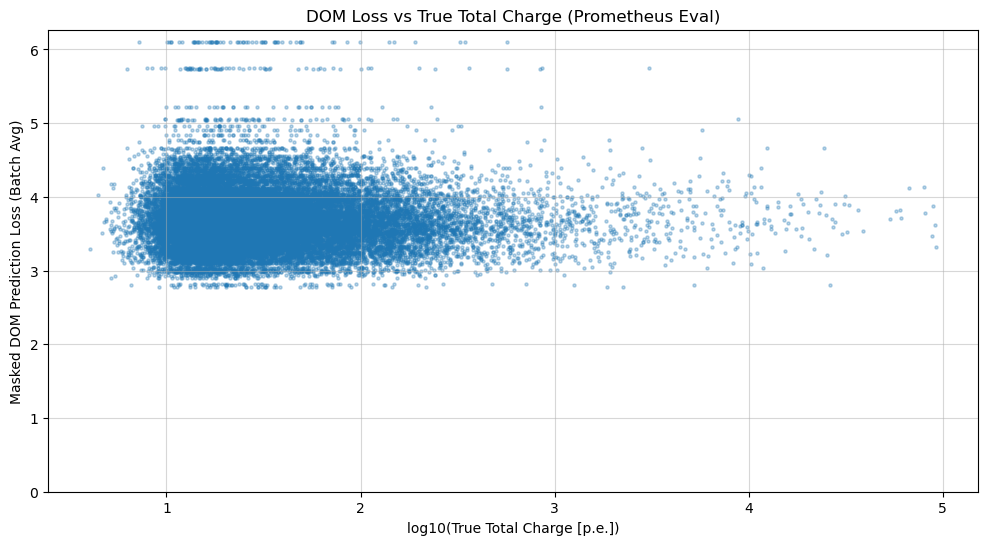

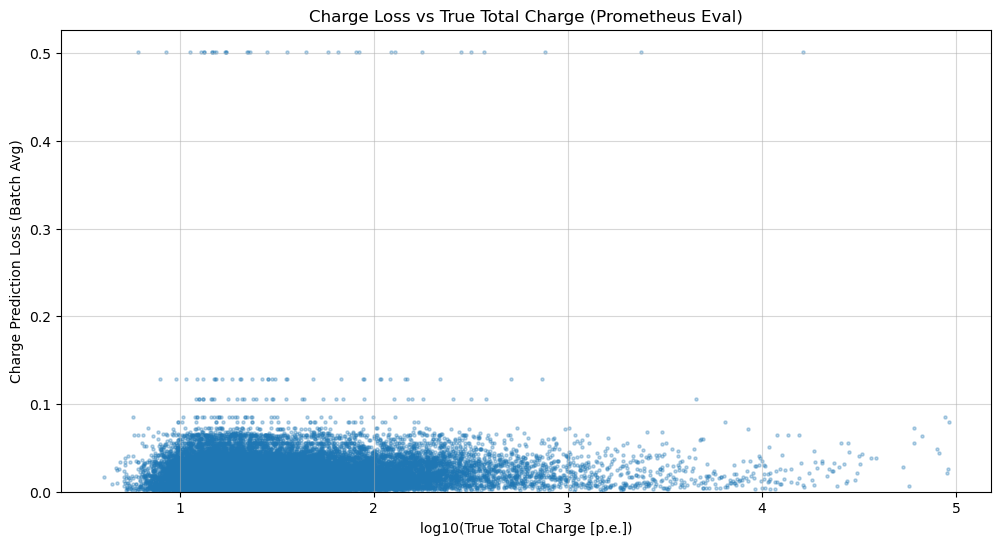

In [64]:

# --- 8. Plotting ---
print("\n--- Generating Plots ---")
if evaluated_batches_count > 0 and batch_true_total_charges:
    # Prepare data for plotting
    plot_dom_losses = []
    plot_charge_losses = []
    plot_charges = []

    for i in range(evaluated_batches_count):
        charges_in_batch = batch_true_total_charges[i]
        dom_loss_for_batch = batch_dom_losses[i]
        charge_loss_for_batch = batch_charge_losses[i]

        # Repeat the batch-average loss for each event in the batch
        plot_dom_losses.extend([dom_loss_for_batch] * len(charges_in_batch))
        if charge_loss_for_batch is not None: # Only plot if charge loss was calculable
             plot_charge_losses.extend([charge_loss_for_batch] * len(charges_in_batch))
        else: # Add NaNs if charge loss was missing for the batch
             plot_charge_losses.extend([np.nan] * len(charges_in_batch))
        plot_charges.extend(list(charges_in_batch))

    plot_dom_losses = np.array(plot_dom_losses)
    plot_charge_losses = np.array(plot_charge_losses)
    plot_charges = np.array(plot_charges)

    # Filter out potential NaN values for plotting charge loss
    valid_charge_loss_mask = ~np.isnan(plot_charge_losses)

    # Use log10 of charge for x-axis, handle potential non-positive values
    plot_log_charges = np.log10(np.maximum(plot_charges, 1e-6)) # Add small epsilon
    plot_log_charges_valid_charge_loss = plot_log_charges[valid_charge_loss_mask]
    plot_charge_losses_valid = plot_charge_losses[valid_charge_loss_mask]


    # Create Plot 1: DOM Loss vs log10(Total Charge)
    plt.figure(figsize=(12, 6))
    plt.scatter(plot_log_charges, plot_dom_losses, alpha=0.3, s=5) # Smaller points, some transparency
    plt.xlabel("log10(True Total Charge [p.e.])")
    plt.ylabel("Masked DOM Prediction Loss (Batch Avg)")
    plt.title("DOM Loss vs True Total Charge (Prometheus Eval)")
    plt.grid(True, alpha=0.5)
    plt.ylim(bottom=0) # Loss shouldn't be negative
    plt.show()

    # Create Plot 2: Charge Loss vs log10(Total Charge)
    if len(plot_charge_losses_valid) > 0:
        plt.figure(figsize=(12, 6))
        plt.scatter(plot_log_charges_valid_charge_loss, plot_charge_losses_valid, alpha=0.3, s=5)
        plt.xlabel("log10(True Total Charge [p.e.])")
        plt.ylabel("Charge Prediction Loss (Batch Avg)")
        plt.title("Charge Loss vs True Total Charge (Prometheus Eval)")
        plt.grid(True, alpha=0.5)
        plt.ylim(bottom=0) # Loss shouldn't be negative
        plt.show()
    else:
        print("Skipping charge loss plot as no valid charge losses were recorded.")

else:
    print("Cannot generate plots: No batches were successfully evaluated or charge data was missing.")


In [65]:

# --- Configuration ---
print("--- Evaluation Setup (Randomly Initialized Model) ---") # Indicate this run
PROMETHEUS_DATA_DIR = '/groups/pheno/inar/prometheus_data/memmaped_pulses'
# Config file path - needed to define model architecture correctly
CONFIG_FILE_FOR_ARCH = "/groups/pheno/inar/PolarBERT/configs/polarbert_new.yaml"

EVAL_BATCH_SIZE = 32
NUM_EVAL_BATCHES = 100 # Use the same number of batches as before
DEVICE = torch.device('cpu')
print(f"Using device: {DEVICE}")
print(f"Using Prometheus data from: {PROMETHEUS_DATA_DIR}")
print(f"Evaluating on {NUM_EVAL_BATCHES} batches.")


--- Evaluation Setup (Randomly Initialized Model) ---
Using device: cpu
Using Prometheus data from: /groups/pheno/inar/prometheus_data/memmaped_pulses
Evaluating on 100 batches.


In [66]:

# --- 1. Load Config (to define model architecture) ---
if not os.path.exists(CONFIG_FILE_FOR_ARCH):
    raise FileNotFoundError(f"Config file not found: {CONFIG_FILE_FOR_ARCH}")
config = PolarBertConfig.from_yaml(CONFIG_FILE_FOR_ARCH)
print("Loaded configuration to define model architecture.")
# Ensure masking is enabled if needed for loss calculation consistency
# config.model.embedding.masking_prob = 0.15 # Or read from config if masking=True passed to model


# --- 2. Instantiate Model (WITHOUT loading weights) ---
print("Instantiating randomly initialized model...")
# Pass masking=True if loss calc relies on output_mask from forward
model_scratch = PolarBertModel(config) # masking=True implied by default or config

# --- 3. Prepare Model for Evaluation ---
model_scratch.eval()
model_scratch.to(DEVICE)
print("Model set to eval mode and moved to CPU.")
param_count_scratch = sum(p.numel() for p in model_scratch.parameters() if p.requires_grad)
print(f'Trainable Parameters (scratch): {param_count_scratch:,}') # Verify parameter count


Loading configuration from: /groups/pheno/inar/PolarBERT/configs/polarbert_new.yaml
Validating configuration...
Configuration validation passed (with potential warnings).
Loaded configuration to define model architecture.
Instantiating randomly initialized model...
INFO: Concatenated embeddings directly match model embedding dim. No projection layer used.
Model set to eval mode and moved to CPU.
Trainable Parameters (scratch): 16,943,345


/lustre/hpc/pheno/inar/PolarBERT/src/polarbert/config.py:327: UserWarning: training.final_div_factor (0.133333) is less than 1.0. For OneCycleLR, this usually leads to a high final LR. Expected >= 1.0 (e.g., 1e4).
  warnings.warn(f"training.final_div_factor ({train_cfg.final_div_factor}) is less than 1.0. "


In [67]:

# --- 4. Create Prometheus DataLoader ---
# (Identical to previous setup)
print("Creating Prometheus DataLoader...")
try:
    prometheus_dataset = PrometheusIceCubeDataset(
        data_dir=PROMETHEUS_DATA_DIR, batch_size=EVAL_BATCH_SIZE,
        transform=default_transform, target_transform=default_target_transform
    )
    prometheus_loader = DataLoader(prometheus_dataset, batch_size=None, num_workers=0)
    print(f"DataLoader created with batch size {EVAL_BATCH_SIZE}.")
except Exception as e:
    print(f"ERROR creating DataLoader: {e}")
    raise e


Creating Prometheus DataLoader...
DataLoader created with batch size 32.


In [68]:

# --- 5. Evaluation Loop ---
print(f"\nStarting evaluation on {NUM_EVAL_BATCHES} batches (Random Model)...")

batch_dom_losses_scratch = []
batch_charge_losses_scratch = []
# No need to store charges again if just comparing loss values

evaluated_batches_count_scratch = 0

with torch.no_grad():
    for i, batch in enumerate(tqdm(prometheus_loader, total=NUM_EVAL_BATCHES, desc="Evaluating Scratch")):
        if i >= NUM_EVAL_BATCHES:
            break

        (x, l), y_data = batch
        true_total_charge_cpu = None
        true_total_charge_dev = None
        if y_data is not None and len(y_data) >= 2:
             # Need charge on device for loss calculation
             true_total_charge_dev = y_data[1].to(DEVICE)

        x = x.to(DEVICE)
        l = l.to(DEVICE)
        batch_dev = ((x,l), None) # Pass None for y_data if handled separately

        try:
            # --- Get model predictions ---
            dom_logits, charge_pred, output_mask, seq_padding_mask = model_scratch.forward(batch_dev)

            # --- Calculate DOM Loss ---
            batch_dom_loss = torch.tensor(0.0, device=DEVICE)
            if output_mask is not None and output_mask.sum() > 0:
                 true_dom_ids = x[:, :, 3].long()
                 dom_targets = true_dom_ids - 1
                 masked_logits = dom_logits[output_mask]
                 masked_targets = dom_targets[output_mask]
                 batch_dom_loss = F.cross_entropy(masked_logits, masked_targets, ignore_index=-1, reduction='mean')

            # --- Calculate Charge Loss ---
            batch_charge_loss = torch.tensor(float('nan'), device=DEVICE)
            if true_total_charge_dev is not None:
                 true_log_charge = torch.log10(torch.clamp(true_total_charge_dev.float(), min=1e-6))
                 batch_charge_loss = F.mse_loss(charge_pred.squeeze(-1).to(true_log_charge.dtype), true_log_charge, reduction='mean')

            # --- Store results for this batch ---
            batch_dom_losses_scratch.append(batch_dom_loss.item())
            batch_charge_losses_scratch.append(batch_charge_loss.item() if not torch.isnan(batch_charge_loss) else None)
            evaluated_batches_count_scratch += 1

        except Exception as e:
            print(f"\nError processing batch {i}: {e}")
            continue

# --- 6. Report Results ---
print("\n--- Evaluation Complete (Randomly Initialized Model) ---")
if evaluated_batches_count_scratch > 0:
    avg_dom_loss_scratch = np.nanmean([l for l in batch_dom_losses_scratch if l is not None])
    avg_charge_loss_scratch = np.nanmean([l for l in batch_charge_losses_scratch if l is not None])
    print(f"Evaluated {evaluated_batches_count_scratch} batches.")
    print(f"Average Masked DOM Loss (Random Init): {avg_dom_loss_scratch:.4f}")
    print(f"Average Charge Loss (Random Init):     {avg_charge_loss_scratch:.4f}")

    # Compare to previous results (manually input or load them)
    avg_dom_loss_pretrained = 3.6971 # From your previous message
    avg_charge_loss_pretrained = 0.0199 # From your previous message
    print("\nComparison:")
    print(f"  DOM Loss: Pre-trained = {avg_dom_loss_pretrained:.4f}, Random = {avg_dom_loss_scratch:.4f}")
    print(f"  Charge Loss: Pre-trained = {avg_charge_loss_pretrained:.4f}, Random = {avg_charge_loss_scratch:.4f}")

    # Calculate expected random DOM loss for reference
    num_dom_classes = config.model.embedding.dom_vocab_size - 2
    expected_random_dom_loss = -np.log(1.0 / num_dom_classes) # Approx -ln(1/N) = ln(N)
    print(f"\nNote: Expected DOM loss for random guessing ({num_dom_classes} classes) is approx. {expected_random_dom_loss:.4f}")

else:
    print("No batches were successfully evaluated.")



Starting evaluation on 100 batches (Random Model)...


Evaluating Scratch:   0%|          | 0/100 [00:00<?, ?it/s]


--- Evaluation Complete (Randomly Initialized Model) ---
Evaluated 100 batches.
Average Masked DOM Loss (Random Init): 8.7288
Average Charge Loss (Random Init):     0.4616

Comparison:
  DOM Loss: Pre-trained = 3.6971, Random = 8.7288
  Charge Loss: Pre-trained = 0.0199, Random = 0.4616

Note: Expected DOM loss for random guessing (5160 classes) is approx. 8.5487
